# Chương 1 — Giới thiệu về Xử lý ngôn ngữ tự nhiên
Nội dung Chương 1:

1. Tổng quan NLP và đặc trưng dữ liệu ngôn ngữ
2. Các cấp độ xử lý ngôn ngữ
3. Corpus và dữ liệu NLP
4. Regular Expressions
5. Tiền xử lý ở cấp độ từ và câu
6. Pipeline tiền xử lý tiếng Việt
7. Phân tích lỗi và so sánh ảnh hưởng của preprocessing

### Yêu cầu
Sinh viên xây dựng một pipeline xử lý **500–1.000 câu tiếng Việt** gồm:

- Unicode normalization
- chuẩn hóa khoảng trắng
- xử lý URL, email, số điện thoại
- sentence segmentation
- tokenization / word segmentation
- thống kê tần suất từ
- Regex extraction
- xử lý emoji / hashtag / mention / teencode
- phân tích ít nhất **5 trường hợp pipeline xử lý sai**

> Mục tiêu không phải chỉ “làm sạch văn bản”, mà phải hiểu **mỗi bước preprocessing làm thay đổi thông tin gì** và khi nào việc làm sạch quá mức có thể làm mô hình kém đi.

# 0. Chuẩn bị môi trường
Notebook dùng các thư viện cơ bản:
- `re`
- `unicodedata`
- `pandas`
- `numpy`
- `scikit-learn`
- `matplotlib`

Phần VnCoreNLP/PhoBERT được để dưới dạng **mở rộng**, không bắt buộc chạy trong notebook offline.

In [1]:
import re
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


# 1. Corpus mẫu tiếng Việt

Để notebook chạy độc lập, ta tạo một corpus nhỏ có chủ đích chứa:
- URL
- email
- số điện thoại
- hashtag
- mention
- emoji
- dấu câu
- teencode
- từ viết tắt
- lỗi khoảng trắng
- một số lỗi gõ tiếng Việt

Trong bài nộp, sinh viên cần thay bằng **500–1.000 câu thực tế**.

In [2]:
BASE_SENTENCES = [
    "Mình rất thích môn NLP này! 😊",
    "Website môn học ở https://nlp.example.edu.vn hoạt động khá ổn.",
    "Liên hệ giảng viên qua email nlp@example.edu.vn.",
    "SĐT hỗ trợ: 0912345678.",
    "@minh ơi, mai học NLP không?",
    "#NLP #AI đang là chủ đề rất thú vị.",
    "Hệ thống hôm nay hơi chậm :(",
    "Ko hiểu sao app cứ lỗi hoài.",
    "Bài này cx khá dễ hiểu.",
    "Mình học xử lý ngôn ngữ tự nhiên vào thứ Hai.",
    "Sinh viên   cần   chuẩn hóa   khoảng trắng.",
    "Dữ liệu tiếng Việt có dấu: hòa, hoà, học, ngôn ngữ.",
    "Email khác: student_01@university.edu.vn",
    "Link tài liệu: http://example.com/nlp?id=123",
    "Mã sinh viên của tôi là 2251234567.",
    "Ngày nộp bài là 12/09/2026.",
    "Phòng học A-203, tầng 2.",
    "Trời nóng quá!!!",
    "Ủa??? sao hệ thống không chạy vậy 😭",
    "Mình thấy môn này khá hay nhưng bài tập hơi nhiều.",
    "Thầy dạy rất dễ hiểu, ví dụ thực tế.",
    "Bài giảng chưa rõ lắm, mong có thêm ví dụ.",
    "NLP có nhiều bài toán như phân loại, NER, QA và RAG.",
    "PhoBERT là mô hình pretrained cho tiếng Việt.",
    "Tách từ tiếng Việt khác tokenization tiếng Anh.",
]

NOISE_VARIANTS = [
    lambda s: s,
    lambda s: "  " + s + "  ",
    lambda s: s.replace("không", "ko"),
    lambda s: s.replace("mình", "mk"),
    lambda s: s.replace("được", "dc"),
    lambda s: s.replace("rất", "rấtt"),
    lambda s: s.replace("học", "hoc"),
]

rows = []
for i in range(600):
    base = random.choice(BASE_SENTENCES)
    text = random.choice(NOISE_VARIANTS)(base)
    rows.append({
        "id": i + 1,
        "text": text,
        "source": random.choice(["feedback", "social", "forum", "support"]),
        "label": random.choice(["neutral", "positive", "negative"])
    })

df = pd.DataFrame(rows)
print("Số câu:", len(df))
display(df.head(10))

Số câu: 600


,id,text,source,label
0,1,"Thầy dạy rất dễ hiểu, ví dụ thực tế.",feedback,negative
1,2,Bài này cx khá dễ hiểu.,social,neutral
2,3,PhoBERT là mô hình pretrained cho tiếng Việt.,feedback,negative
3,4,Link tài liệu: http://example.com/nlp?id=123,feedback,neutral
4,5,Hệ thống hôm nay hơi chậm :(,feedback,negative
5,6,Hệ thống hôm nay hơi chậm :(,support,neutral
6,7,Mã sinh viên của tôi là 2251234567.,forum,neutral
7,8,Tách từ tiếng Việt khác tokenization tiếng Anh.,social,negative
8,9,Link tài liệu: http://example.com/nlp?id=123,forum,neutral
9,10,Hệ thống hôm nay hơi chậm :(,forum,neutral


## Task 1: Corpus, document, sentence, token, vocabulary

### Code mẫu
- **Corpus**: toàn bộ tập dữ liệu văn bản.
- **Document**: một đơn vị văn bản độc lập.
- **Sentence**: câu.
- **Token**: đơn vị sau khi tokenization.
- **Vocabulary**: tập token duy nhất.

Trong notebook này, mỗi dòng `text` được xem là một document ngắn.

In [3]:
def simple_tokens(text):
    return str(text).split()

all_tokens = []
for text in df["text"]:
    all_tokens.extend(simple_tokens(text))

vocab = set(all_tokens)

print("Documents:", len(df))
print("Tokens:", len(all_tokens))
print("Vocabulary size:", len(vocab))
print("10 token phổ biến:", Counter(all_tokens).most_common(10))

Documents: 600
Tokens: 4415
Vocabulary size: 152
10 token phổ biến: [('tiếng', 101), ('là', 95), ('viên', 84), ('khá', 80), ('có', 77), ('môn', 76), ('bài', 74), ('học', 73), ('Mình', 67), ('NLP', 62)]


### Yêu cầu Task 1
1. Tính:
   - số document,
   - số sentence,
   - tổng token,
   - vocabulary size.
2. Tính:
   - độ dài câu trung bình,
   - median,
   - min/max.
3. Vẽ histogram độ dài câu.
4. So sánh vocabulary trước và sau lowercase.
5. Tìm 30 token hiếm nhất và 30 token phổ biến nhất.
6. Giải thích vì sao vocabulary quá lớn có thể gây khó khăn cho mô hình truyền thống.

### TODO

In [4]:
def corpus_statistics(texts):
    # TODO: trả về dictionary thống kê corpus
    pass

# 2. Dữ liệu có nhãn / không nhãn và Train–Validation–Test

Dữ liệu NLP có thể:
- **labeled**: có nhãn sentiment, topic, entity...
- **unlabeled**: chỉ có văn bản.

Khi huấn luyện supervised model, thường chia:
- train
- validation
- test

In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 420
Validation: 90
Test: 90


## Task 2: Data split và Data Leakage

### Ví dụ leakage
Nếu ta:
1. fit vocabulary hoặc TF-IDF trên **toàn bộ dữ liệu**,
2. sau đó mới chia train/test,

thì thông tin từ test đã “rò rỉ” vào bước huấn luyện.

### Yêu cầu
1. Kiểm tra duplicate giữa train/val/test.
2. Xóa duplicate trước khi split.
3. Nếu dữ liệu có `user_id`, đề xuất cách split tránh cùng user xuất hiện ở train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split.
5. Giải thích ít nhất 3 dạng data leakage trong NLP.

### TODO

In [6]:
def exact_overlap(a, b):
    return len(set(a) & set(b))

print("Train/Test exact overlap:",
      exact_overlap(train_df["text"], test_df["text"]))

# TODO: deduplicate rồi split lại

Train/Test exact overlap: 40


# 3. Mất cân bằng nhãn

Nếu một lớp chiếm đa số, Accuracy có thể đánh lừa.

Ví dụ:
- positive: 80%
- neutral: 15%
- negative: 5%

Một model luôn đoán positive vẫn có Accuracy cao.

label
neutral     208
negative    204
positive    188
Name: count, dtype: int64


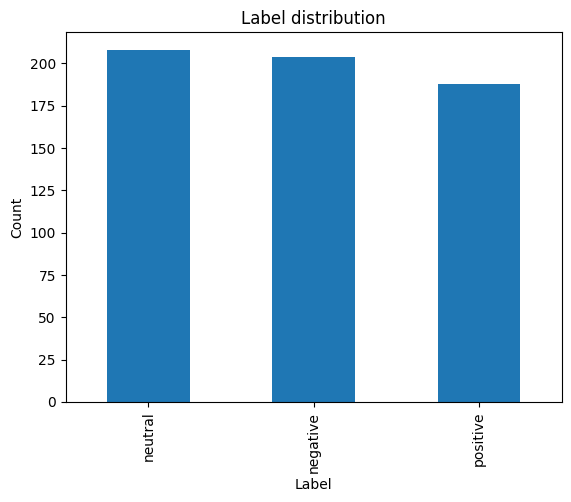

In [7]:
label_dist = df["label"].value_counts()
print(label_dist)

label_dist.plot(kind="bar")
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## Task 3: Imbalance
1. Tạo một phiên bản dữ liệu mất cân bằng mạnh.
2. Tính tỷ lệ từng lớp.
3. Đề xuất:
   - class weight,
   - over-sampling,
   - under-sampling.
4. Giải thích khi nào **macro-F1** phù hợp hơn Accuracy.

# 4. Gán nhãn dữ liệu và Inter-Annotator Agreement

Khi nhiều annotator gán nhãn cùng dữ liệu, ta cần đo mức độ thống nhất.

Một metric phổ biến: **Cohen's Kappa**.

\[
\kappa = 
rac{p_o - p_e}{1 - p_e}
\]

Trong đó:
- \(p_o\): agreement quan sát được
- \(p_e\): agreement kỳ vọng do ngẫu nhiên

In [8]:
annotator_a = [
    "positive","positive","neutral","negative","positive",
    "neutral","negative","positive","neutral","negative"
]

annotator_b = [
    "positive","neutral","neutral","negative","positive",
    "neutral","negative","positive","negative","negative"
]

kappa = cohen_kappa_score(annotator_a, annotator_b)
print("Cohen's kappa =", round(kappa, 3))

Cohen's kappa = 0.701


## Task 4: Annotation Guideline
1. Tạo 30 câu khó gán nhãn sentiment.
2. Cho 2 người gán nhãn độc lập.
3. Tính Cohen's Kappa.
4. Liệt kê ít nhất 5 disagreement.
5. Viết guideline ngắn giúp giảm disagreement.
6. Thảo luận:
   - sarcasm,
   - câu vừa khen vừa chê,
   - câu thiếu ngữ cảnh.

### TODO

In [9]:
def agreement_report(labels_a, labels_b):
    # TODO:
    # - agreement %
    # - Cohen's kappa
    # - danh sách vị trí bất đồng
    pass

# 5. Regular Expressions — mẫu cơ bản

Regex = ngôn ngữ mô tả **pattern ký tự**.

Ta sẽ dùng Regex để:
- email
- URL
- số điện thoại
- ngày tháng
- hashtag
- mention
- mã sinh viên

In [10]:
sample = """
Liên hệ: nlp@example.edu.vn
Website: https://nlp.example.edu.vn/course?id=3
SĐT: 0912345678
Ngày: 12/09/2026
Sinh viên: @minh
Hashtag: #NLP
MSSV: 2251234567
"""

EMAIL_RE = r"[\w.-]+@[\w.-]+\.\w+"
URL_RE = r"https?://[^\s]+"
PHONE_RE = r"\b0\d{9}\b"
DATE_RE = r"\b\d{1,2}/\d{1,2}/\d{4}\b"
HASHTAG_RE = r"#\w+"
MENTION_RE = r"@\w+"
STUDENT_ID_RE = r"\b\d{10}\b"

patterns = {
    "email": EMAIL_RE,
    "url": URL_RE,
    "phone": PHONE_RE,
    "date": DATE_RE,
    "hashtag": HASHTAG_RE,
    "mention": MENTION_RE,
    "student_id": STUDENT_ID_RE,
}

for name, pattern in patterns.items():
    print(name, "=>", re.findall(pattern, sample))

email => ['nlp@example.edu.vn']
url => ['https://nlp.example.edu.vn/course?id=3']
phone => ['0912345678']
date => ['12/09/2026']
hashtag => ['#NLP']
mention => ['@example', '@minh']
student_id => ['0912345678', '2251234567']


## Task 5: Regex extraction
Sinh viên phải mở rộng Regex để trích xuất:

1. Email
2. URL
3. Số điện thoại Việt Nam
4. Ngày `dd/mm/yyyy` và `dd-mm-yyyy`
5. Hashtag
6. Mention
7. Mã sinh viên
8. Mã môn học dạng ví dụ `CS101`, `NLP202`
9. Mã phòng dạng `A-203`
10. Số tiền dạng `1.200.000đ`

### Yêu cầu
- Tạo ít nhất 10 test case đúng.
- Tạo ít nhất 10 test case sai.
- Đo precision/recall đơn giản cho từng pattern.

### TODO

In [11]:
COURSE_CODE_RE = r"\b[A-Z]{2,4}\d{2,4}\b"
ROOM_RE = r"\b[A-Z]-\d{2,4}\b"

def extract_patterns(text):
    return {
        "email": re.findall(EMAIL_RE, text),
        "url": re.findall(URL_RE, text),
        # TODO: bổ sung các trường khác
    }

# 6. Hạn chế của Regex

Regex rất mạnh với cấu trúc hình thức rõ ràng, nhưng không hiểu ngữ nghĩa.

Ví dụ:
- Regex có thể tìm `bank`
- nhưng không biết `bank` = ngân hàng hay bờ sông.
- Regex có thể tách câu theo dấu `.`
- nhưng dễ sai với viết tắt hoặc số thập phân.

## Task 6: Failure cases của Regex
Tìm ít nhất 10 trường hợp Regex xử lý sai, ví dụ:
- email lạ
- URL có dấu ngoặc cuối
- số điện thoại có `+84`
- ngày không hợp lệ `32/13/2026`
- dấu chấm trong viết tắt
- số thập phân
- emoji / Unicode lạ

Với mỗi lỗi:
- input,
- regex,
- output,
- lý do sai,
- đề xuất sửa.

# 7. Unicode Normalization

Tiếng Việt có thể được mã hóa theo nhiều cách Unicode khác nhau.

Hai chuỗi nhìn giống nhau trên màn hình nhưng có thể có sequence code point khác nhau.

Ta thường chuẩn hóa về dạng **NFC**.

In [12]:
s1 = "hoà"
s2 = unicodedata.normalize("NFD", s1)

print("s1:", s1)
print("s2:", s2)
print("Equal before NFC?", s1 == s2)
print("Equal after NFC?",
      unicodedata.normalize("NFC", s1) == unicodedata.normalize("NFC", s2))

print("Code points s1:", [hex(ord(c)) for c in s1])
print("Code points s2:", [hex(ord(c)) for c in s2])

s1: hoà
s2: hoà
Equal before NFC? False
Equal after NFC? True
Code points s1: ['0x68', '0x6f', '0xe0']
Code points s2: ['0x68', '0x6f', '0x61', '0x300']


## Task 7: Unicode
1. Tạo 10 cặp chuỗi NFC/NFD.
2. Chứng minh nhìn giống nhưng `==` có thể False.
3. So sánh vocabulary trước/sau NFC.
4. Kiểm tra regex và tokenization có thay đổi không.
5. Giải thích tại sao Unicode normalization nên nằm **rất sớm** trong pipeline.

In [13]:
def normalize_unicode(text):
    return unicodedata.normalize("NFC", str(text))

# TODO: thống kê vocab trước và sau Unicode normalization

# 8. Chuẩn hóa chữ hoa/chữ thường và khoảng trắng

In [14]:
def basic_normalize(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

examples = [
    "  SINH   VIÊN học NLP  ",
    "Mình   RẤT thích môn này!!!",
]

for x in examples:
    print("RAW :", repr(x))
    print("NORM:", repr(basic_normalize(x)))
    print()

RAW : '  SINH   VIÊN học NLP  '
NORM: 'sinh viên học nlp'

RAW : 'Mình   RẤT thích môn này!!!'
NORM: 'mình rất thích môn này!!!'



## Task 8: Normalization policy
So sánh các lựa chọn:
- lowercase / giữ nguyên case
- giữ / bỏ dấu câu
- giữ / bỏ emoji
- giữ / bỏ hashtag
- giữ / bỏ URL

Với mỗi lựa chọn, trả lời:
- thông tin nào bị mất?
- mô hình truyền thống có lợi không?
- Transformer có nhất thiết cần bước này không?

# 9. Sentence Segmentation

Trong code mẫu đơn giản nhất: tách theo `. ! ?`

Nhưng có nhiều trường hợp khó:
- `TS. Nguyễn Văn A`
- `3.14`
- `example.com`
- `v.v.`

In [15]:
def simple_sentence_split(text):
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p for p in parts if p]

text = "NLP rất thú vị. Bạn học chưa? Mình học rồi! Website là example.com nhé."
simple_sentence_split(text)

['NLP rất thú vị.',
 'Bạn học chưa?',
 'Mình học rồi!',
 'Website là example.com nhé.']

## Task 9: Sentence segmentation
1. Tạo ít nhất 20 câu kiểm thử.
2. Bao gồm:
   - abbreviation,
   - URL,
   - số thập phân,
   - dấu `...`,
   - emoji.
3. Cải tiến regex splitter.
4. So sánh với thư viện NLP nếu có.
5. Báo cáo ít nhất 5 lỗi còn lại.

In [16]:
def improved_sentence_split(text):
    # TODO: cải tiến splitter
    return simple_sentence_split(text)

# 10. Tokenization

Tokenization quyết định đơn vị cơ bản để mô hình xử lý.

Ví dụ:

`"Tôi học NLP."`

có thể thành:
- `["Tôi", "học", "NLP", "."]`

Không nên mặc định `split()` là tokenizer hoàn chỉnh.

In [17]:
TOKEN_RE = r"\w+|[^\w\s]"

def regex_tokenize(text):
    return re.findall(TOKEN_RE, text, flags=re.UNICODE)

text = "Mình thích NLP! 😊 #AI"
print(regex_tokenize(text))

['Mình', 'thích', 'NLP', '!', '😊', '#', 'AI']


## Task 10: Tokenizer
1. So sánh:
   - `str.split()`
   - Regex tokenizer
2. Kiểm thử:
   - `email@example.com`
   - `#NLP`
   - `@user`
   - emoji
   - `12/09/2026`
3. Tự định nghĩa policy:
   - giữ hashtag nguyên token?
   - giữ emoji?
   - URL thành một token hay nhiều token?

In [18]:
def my_tokenizer(text):
    # TODO: thiết kế tokenizer của nhóm
    pass

# 11. Từ, âm tiết và subword trong tiếng Việt

Tiếng Việt có khoảng trắng giữa **âm tiết**, không phải lúc nào cũng giữa **từ**.

Ví dụ:

`"sinh viên học xử lý ngôn ngữ tự nhiên"`

Một số từ đa âm tiết:
- `sinh viên`
- `xử lý`
- `ngôn ngữ`
- `tự nhiên`

Vì vậy:
- whitespace tokenization ≠ word segmentation.

In [19]:
text = "sinh viên học xử lý ngôn ngữ tự nhiên"
print("Whitespace units:", text.split())

Whitespace units: ['sinh', 'viên', 'học', 'xử', 'lý', 'ngôn', 'ngữ', 'tự', 'nhiên']


## Task 11: Word segmentation tiếng Việt
### Code mẫu thủ công chỉ để minh họa
Ta có thể viết:
`"sinh_viên học xử_lý ngôn_ngữ tự_nhiên"`

### Yêu cầu
1. Chạy một bộ tách từ tiếng Việt thực tế:
   - VnCoreNLP/RDRSegmenter
   - underthesea
   - công cụ tương đương
2. So sánh với whitespace split trên ít nhất 50 câu.
3. Tìm 10 trường hợp khác nhau.
4. Phân tích khi nào word segmentation sai.

### PhoBERT
Đối với PhoBERT, dữ liệu đầu vào dạng từ nên được word-segment theo cách tương thích với dữ liệu pretraining; tài liệu/kho mã chính thức thường dùng RDRSegmenter trong VnCoreNLP.

In [20]:
# Lưu ý: đây là code mẫu minh họa chứ không phải word segmenter thực tế
KNOWN_MULTI_SYLLABLE_WORDS = [
    "sinh viên",
    "xử lý",
    "ngôn ngữ",
    "tự nhiên",
    "trí tuệ",
    "nhân tạo",
]

def toy_word_segment(text):
    text = basic_normalize(text)
    for phrase in sorted(KNOWN_MULTI_SYLLABLE_WORDS, key=len, reverse=True):
        text = text.replace(phrase, phrase.replace(" ", "_"))
    return text

print(toy_word_segment(
    "Sinh viên học xử lý ngôn ngữ tự nhiên và trí tuệ nhân tạo"
))

sinh_viên học xử_lý ngôn_ngữ tự_nhiên và trí_tuệ nhân_tạo


### TODO — Word segmentation thật
Sinh viên cài đặt thư viện ngoài notebook nếu cần.

Ví dụ scaffold:

```python
# from vncorenlp import VnCoreNLP
# rdrsegmenter = VnCoreNLP(..., annotators="wseg")
# segmented = rdrsegmenter.tokenize(text)
```

Yêu cầu: ghi rõ phiên bản công cụ và preprocessing đã dùng.

# 12. Stopword Removal

Stopword = từ rất phổ biến và đôi khi ít mang thông tin cho một task.

Nhưng **không phải lúc nào cũng nên xóa stopword**.

Ví dụ sentiment:
- `không tốt`
Nếu xóa `"không"` → mất hoàn toàn polarity.

In [21]:
STOPWORDS = {"là", "và", "của", "có", "một", "những"}

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS]

text = "môn này không tốt và có quá nhiều bài tập"
tokens = basic_normalize(text).split()

print("Before:", tokens)
print("After :", remove_stopwords(tokens))

Before: ['môn', 'này', 'không', 'tốt', 'và', 'có', 'quá', 'nhiều', 'bài', 'tập']
After : ['môn', 'này', 'không', 'tốt', 'quá', 'nhiều', 'bài', 'tập']


## Task 12: Stopword
1. Tự xây stopword list.
2. So sánh:
   - vocabulary size,
   - TF-IDF accuracy
   trước/sau stopword removal.
3. Tạo 10 ví dụ mà xóa stopword làm sai nghĩa.
4. Quyết định có nên xóa:
   - `không`,
   - `chưa`,
   - `rất`,
   - `nhưng`.

# 13. Stemming và Lemmatization

### Stemming
Cắt hậu tố theo rule.

### Lemmatization
Đưa từ về lemma dựa trên từ điển/ngữ pháp.

Ví dụ tiếng Anh:
- studies → study
- running → run

Với tiếng Việt, morphology biến đổi ít hơn tiếng Anh nên stemming kiểu Porter không phải bước mặc định quan trọng như trong tiếng Anh.

## Task 13: Stemming/Lemmatization
1. Với một tập dữ liệu tiếng Anh nhỏ, thử stemming/lemmatization.
2. Với tiếng Việt, tìm các trường hợp:
   - từ ghép,
   - từ láy,
   - biến thể cách viết
   mà không thể giải quyết tốt bằng stemming kiểu tiếng Anh.
3. Giải thích vì sao word segmentation thường quan trọng hơn stemming trong nhiều pipeline tiếng Việt.

# 14. Teencode, từ viết tắt và slang

In [22]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được",
    "đc": "được",
    "mk": "mình",
    "cx": "cũng",
    "ntn": "như thế nào",
}

def normalize_teencode(text):
    toks = basic_normalize(text).split()
    toks = [TEENCODE_MAP.get(t, t) for t in toks]
    return " ".join(toks)

for x in [
    "mk ko hiểu bài này",
    "bài này cx dc",
    "ntn mới đúng vậy",
]:
    print(x, "=>", normalize_teencode(x))

mk ko hiểu bài này => mình không hiểu bài này
bài này cx dc => bài này cũng được
ntn mới đúng vậy => như thế nào mới đúng vậy


## Task 14: Teencode
1. Mở rộng dictionary lên ít nhất 50 mapping.
2. Thêm mapping theo domain.
3. Xử lý trường hợp một viết tắt có nhiều nghĩa.
4. Đánh giá:
   - coverage,
   - false normalization.
5. Tìm 10 trường hợp dictionary thay sai.

# 15. URL, email, phone, hashtag, mention và emoji

Thay vì xóa hoàn toàn, ta có thể **thay bằng special token**:

- URL → `<URL>`
- email → `<EMAIL>`
- phone → `<PHONE>`
- mention → `<USER>`

Ưu điểm:
- giữ thông tin “có URL/email”,
- giảm vocabulary.

In [23]:
def replace_special_patterns(text):
    text = str(text)
    text = re.sub(URL_RE, "<URL>", text)
    text = re.sub(EMAIL_RE, "<EMAIL>", text)
    text = re.sub(PHONE_RE, "<PHONE>", text)
    text = re.sub(MENTION_RE, "<USER>", text)
    return text

x = "Nhắn @minh qua nlp@example.edu.vn hoặc 0912345678, xem https://example.com"
print(replace_special_patterns(x))

Nhắn <USER> qua <EMAIL> hoặc <PHONE>, xem <URL>


## Task 15: Replace hay Remove?
So sánh 3 policy:
1. giữ nguyên,
2. xóa,
3. replace special token.

Đánh giá tác động tới:
- vocabulary size,
- TF-IDF feature space,
- classification accuracy.

# 16. Emoji

Emoji có thể mang sentiment mạnh:
- 😊 👍 ❤️ → positive
- 😡 😭 👎 → negative

Xóa emoji có thể làm mất tín hiệu.

In [24]:
EMOJI_MAP = {
    "😊": "<EMO_POS>",
    "😀": "<EMO_POS>",
    "👍": "<EMO_POS>",
    "😡": "<EMO_NEG>",
    "😭": "<EMO_NEG>",
    "👎": "<EMO_NEG>",
    "😐": "<EMO_NEU>",
}

def normalize_emoji(text):
    out = str(text)
    for emo, tag in EMOJI_MAP.items():
        out = out.replace(emo, f" {tag} ")
    return re.sub(r"\s+", " ", out).strip()

for x in ["Môn này hay 😊", "App lỗi 😡", "Cũng bình thường 😐"]:
    print(x, "=>", normalize_emoji(x))

Môn này hay 😊 => Môn này hay <EMO_POS>
App lỗi 😡 => App lỗi <EMO_NEG>
Cũng bình thường 😐 => Cũng bình thường <EMO_NEU>


## Task 16: Emoji
1. Mở rộng emoji lexicon.
2. So sánh:
   - remove emoji,
   - keep raw emoji,
   - map emoji → sentiment tags.
3. Tìm ví dụ emoji mỉa mai hoặc đảo nghĩa.

# 17. Chuẩn hóa dấu thanh và lỗi gõ tiếng Việt

Đây là phần khó và không nên giải quyết chỉ bằng vài Regex.

Các lỗi thường gặp:
- mất dấu: `hoc` → `học`
- dấu sai vị trí
- Telex/VNI chưa hoàn tất
- Unicode tổ hợp
- `hoà` / `hòa`

Lưu ý: ở Chương 1, mục tiêu là **nhận diện vấn đề** và thiết kế pipeline. Về phần thuật toán sửa lỗi chính tả chi tiết sẽ được giới thiệu ở Chương 2.

## Task 17: Vietnamese normalization
1. Thu thập 30 lỗi gõ tiếng Việt.
2. Phân nhóm:
   - Unicode,
   - missing tone,
   - Telex/VNI,
   - wrong tone,
   - spacing.
3. Viết rule cho các lỗi đơn giản.
4. Ghi rõ các lỗi không thể xử lý đáng tin bằng rule.

# 18. Xây dựng pipeline tiền xử lý hoàn chỉnh

Pipeline mẫu:

```text
Raw text
   ↓
Unicode NFC
   ↓
Replace URL/email/phone
   ↓
Whitespace normalization
   ↓
Teencode normalization
   ↓
Sentence segmentation
   ↓
Tokenization / word segmentation
   ↓
Optional stopword policy
   ↓
Output
```

In [25]:
def preprocess_text(text):
    # 1. Unicode
    text = unicodedata.normalize("NFC", str(text))

    # 2. Replace special patterns
    text = replace_special_patterns(text)

    # 3. Emoji
    text = normalize_emoji(text)

    # 4. Lowercase + whitespace
    text = basic_normalize(text)

    # 5. Teencode
    text = normalize_teencode(text)

    # 6. Demo word segmentation
    text = toy_word_segment(text)

    return text

examples = [
    "  MK ko hiểu bài NLP này 😭  ",
    "Liên hệ @minh qua nlp@example.edu.vn nhé!",
    "Sinh viên học xử lý ngôn ngữ tự nhiên.",
]

for x in examples:
    print("RAW :", x)
    print("PROC:", preprocess_text(x))
    print()

RAW :   MK ko hiểu bài NLP này 😭  
PROC: mình không hiểu bài nlp này <emo_neg>

RAW : Liên hệ @minh qua nlp@example.edu.vn nhé!
PROC: liên hệ <user> qua <email> nhé!

RAW : Sinh viên học xử lý ngôn ngữ tự nhiên.
PROC: sinh_viên học xử_lý ngôn_ngữ tự_nhiên.



## Task 18: Pipeline cải tiến
Sinh viên phải tạo `preprocess_text_v2()` có cấu hình:

```python
preprocess_text_v2(
    text,
    lowercase=True,
    replace_url=True,
    replace_email=True,
    normalize_teencode=True,
    keep_emoji=True,
    word_segment=True,
    remove_stopwords=False
)
```

### Yêu cầu
- mỗi bước bật/tắt được,
- ghi log trước/sau,
- có unit test cho ít nhất 20 input.

In [26]:
def preprocess_text_v2(
    text,
    lowercase=True,
    replace_url=True,
    replace_email=True,
    normalize_teencode_flag=True,
    keep_emoji=True,
    word_segment=True,
    remove_stopwords_flag=False,
):
    # TODO: sinh viên hoàn thiện pipeline cấu hình
    pass

# 19. Thống kê trước và sau preprocessing

In [27]:
df["processed"] = df["text"].map(preprocess_text)

def vocab_stats(texts):
    toks = []
    for t in texts:
        toks.extend(str(t).split())
    return {
        "tokens": len(toks),
        "vocab": len(set(toks)),
        "avg_tokens_per_doc": len(toks) / max(1, len(texts)),
    }

before_stats = vocab_stats(df["text"])
after_stats = vocab_stats(df["processed"])

print("Before:", before_stats)
print("After :", after_stats)

Before: {'tokens': 4415, 'vocab': 152, 'avg_tokens_per_doc': 7.358333333333333}
After : {'tokens': 4278, 'vocab': 143, 'avg_tokens_per_doc': 7.13}


## Task 19: So sánh trước/sau
Tạo bảng:

| Metric | Raw | Processed | % change |
|---|---:|---:|---:|
| Vocabulary size | | | |
| Avg tokens/doc | | | |
| Unique URL tokens | | | |
| Unique email tokens | | | |
| Rare tokens | | | |

Giải thích:
- vì sao vocabulary giảm/tăng?
- thông tin nào đã mất?
- thông tin nào được chuẩn hóa tốt hơn?

# 20. Ảnh hưởng preprocessing tới mô hình truyền thống

Ta dùng một baseline nhỏ:
**TF-IDF + Logistic Regression**

Mục tiêu không phải đạt accuracy cao trên dataset tổng hợp, mà để quan sát:
- raw text
- processed text
có thể tạo feature space khác nhau.

In [28]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

def train_eval_text_column(column):
    X_train = df.iloc[train_idx][column]
    X_test = df.iloc[test_idx][column]
    y_train = df.iloc[train_idx]["label"]
    y_test = df.iloc[test_idx]["label"]

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    return accuracy_score(y_test, pred), pipe

raw_acc, raw_model = train_eval_text_column("text")
proc_acc, proc_model = train_eval_text_column("processed")

print("Raw accuracy      :", round(raw_acc, 4))
print("Processed accuracy:", round(proc_acc, 4))

Raw accuracy      : 0.3933
Processed accuracy: 0.3933


## Task 20: Ablation Study
Sinh viên cần tạo nhiều phiên bản:
- Raw
- + NFC
- + lowercase
- + URL/email replacement
- + teencode normalization
- + emoji mapping
- + word segmentation
- + stopword removal

Sau đó báo cáo:

| Pipeline | Vocab size | Accuracy | Macro F1 |

### Câu hỏi
1. Bước nào cải thiện rõ nhất?
2. Bước nào làm giảm kết quả?
3. Có preprocessing nào “thừa” không?

# 21. Transformer và preprocessing

Transformer pretrained thường **không cần** preprocessing mạnh như pipeline truyền thống.

Không nên tự động:
- stem,
- xóa dấu câu,
- xóa stopword,
- xóa emoji

nếu tokenizer/model pretrained đã học từ dữ liệu chứa các tín hiệu đó.

Với PhoBERT:
- word segmentation cần tương thích với preprocessing lúc pretraining.

## Task 21: Traditional vs Transformer
Tạo bảng so sánh:

| Bước | TF-IDF model | Transformer |
|---|---|---|
| Lowercase | có thể hữu ích | tùy pretrained model |
| Stopword removal | đôi khi hữu ích | thường không cần |
| Stemming | có thể thử | thường không |
| Emoji removal | task-dependent | thường nên giữ |
| Word segmentation | rất quan trọng với word features | phụ thuộc tokenizer/model |
| URL replacement | thường hữu ích | task-dependent |

Sinh viên phải giải thích **không có một pipeline preprocessing tối ưu cho mọi mô hình**.

# 22. Error Analysis (bắt buộc)

Sinh viên phải phân tích ít nhất **5 trường hợp pipeline xử lý sai**.

Nên có nhiều loại lỗi:
- regex sai
- sentence splitting sai
- tokenization sai
- word segmentation sai
- teencode normalization sai
- emoji bị mất nghĩa
- URL/email regex ăn thừa dấu câu
- stopword removal làm đổi nghĩa

In [29]:
error_analysis = [
    # Ví dụ:
    # {
    #   "input": "Môn này không tốt!",
    #   "expected": "...",
    #   "actual": "...",
    #   "stage": "stopword",
    #   "reason": "xóa từ phủ định 'không'",
    #   "proposed_fix": "không đưa 'không' vào stopword list"
    # }
]

pd.DataFrame(error_analysis)

""


## Task 22: Phân loại failure cases
Tạo bảng gồm:

| Input | Expected | Actual | Stage | Cause | Proposed fix |


Ít nhất 5 lỗi, khuyến khích 10–20 lỗi.

Lưu ý: cần xác định rõ **sai ở bước nào**.

# 23. Đạo đức dữ liệu NLP

Khi thu thập dữ liệu văn bản, cần chú ý:
- PII: email, số điện thoại, tên riêng
- dữ liệu nhạy cảm
- toxic content
- bias theo giới, vùng miền, nhóm xã hội
- consent / điều khoản sử dụng dữ liệu

Regex có thể được dùng để **mask PII** trước khi chia sẻ dataset.

In [30]:
def mask_pii(text):
    text = re.sub(EMAIL_RE, "<EMAIL>", str(text))
    text = re.sub(PHONE_RE, "<PHONE>", text)
    return text

print(mask_pii(
    "Liên hệ nlp@example.edu.vn hoặc 0912345678"
))

Liên hệ <EMAIL> hoặc <PHONE>


## Task 23: Data ethics
1. Tạo danh sách trường dữ liệu cần ẩn.
2. Viết pipeline mask PII.
3. Kiểm tra 20 câu chứa PII.
4. Tìm false positive / false negative.
5. Giải thích vì sao “xóa tên” chưa chắc đủ để ẩn danh hoàn toàn.

# 24. Bài về nhà

Sinh viên chọn 500–1.000 câu tiếng Việt và xây pipeline:

### Bắt buộc
1. Unicode NFC
2. Khoảng trắng
3. URL/email/phone
4. Sentence segmentation
5. Tokenization
6. Word segmentation
7. Tần suất từ
8. Regex extraction
9. Teencode / emoji / hashtag / mention
10. So sánh raw vs processed
11. Error analysis

### Đầu ra notebook
- thống kê corpus,
- biểu đồ,
- code pipeline,
- test cases,
- bảng failure cases,
- kết luận.

# 25. Yêu cầu cải tiến

Ngoài pipeline mẫu, sinh viên phải thực hiện ít nhất **3 cải tiến**:

- [ ] Regex robust hơn
- [ ] Sentence splitter tốt hơn
- [ ] Custom tokenizer
- [ ] Word segmentation bằng VnCoreNLP
- [ ] Teencode dictionary ≥ 50 entries
- [ ] Emoji normalization
- [ ] PII masking
- [ ] Stopword ablation
- [ ] Preprocessing configuration
- [ ] Unit tests
- [ ] So sánh ảnh hưởng trên TF-IDF classifier
- [ ] So sánh với tokenizer của pretrained model

# 26. Bảng kết quả

| Thành phần | Baseline | Improved | Nhận xét |
|---|---|---|---|
| Regex email | | | |
| Regex phone | | | |
| Sentence split | | | |
| Tokenization | | | |
| Word segmentation | | | |
| Teencode | | | |
| Vocabulary size | | | |
| TF-IDF accuracy | | | |
| Failure cases | | | |

Mỗi cải tiến phải có:
1. vấn đề,
2. giả thuyết,
3. thay đổi,
4. kết quả,
5. kết luận.

# 27. Rubric

| Thành phần | Điểm |
|---|---:|
| Corpus + thống kê dữ liệu | 10 |
| Train/val/test + leakage | 10 |
| Regex extraction | 15 |
| Unicode + normalization | 10 |
| Sentence segmentation + tokenization | 15 |
| Word segmentation tiếng Việt | 10 |
| Pipeline hoàn chỉnh | 10 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis | 5 |
| Data ethics + trình bày | 5 |
| **Tổng** | **100** |

### Điểm cộng
- VnCoreNLP integration
- unit test tốt
- benchmark tốc độ
- PII masking tốt
- ablation study rõ ràng